## Expected Profit

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [2]:
# Load test features
X_test  = pd.read_csv("X_test.csv")
y_test  = pd.read_csv("y_test.csv").values.ravel()

# Load trained model
xgb_clf = joblib.load("xgb_champion_model.pkl")

# Generate predicted probabilities
test_probs = xgb_clf.predict_proba(X_test)[:, 1]

## LDG Sensitivity

In [18]:
def expected_value_decision_table(X, y, pd_pred):
    L = X["loan_amnt"].to_numpy()
    r = (X["int_rate"].to_numpy() / 100.0)
    lgd_list = np.arange(0.001, 1.01, 0.1)

    rows = []
    for LGD in lgd_list:
        # Expected components per loan
        EL  = pd_pred * LGD * L                      # Expected Loss
        EI  = (1 - pd_pred) * r * L                  # Expected Interest income (1-year proxy)
        ENV = EI - EL                                # Expected Net Value

        approve = ENV > 0

        rows.append({
            "LGD": LGD,
            "approval_rate": float(approve.mean()),
            "n_approved": int(approve.sum()),
            "expected_total_value": float(ENV[approve].sum()),
            "expected_interest_income": float(EI[approve].sum()),
            "expected_loss": float(EL[approve].sum()),
            "realized_default_rate_approved": float(y[approve].mean()),
            "avg_pred_pd_approved": float(pd_pred[approve].mean()) if approve.any() else np.nan
        })

    return pd.DataFrame(rows)

In [19]:
# Example usage (XGBoost test probabilities)
ev_table = expected_value_decision_table(X_test, y_test, test_probs)
ev_table

,LGD,approval_rate,n_approved,expected_total_value,expected_interest_income,expected_loss,realized_default_rate_approved,avg_pred_pd_approved
0,0.001,1.000000,225639,3.346734e+08,3.354223e+08,7.489270e+05,0.212920,0.206590
1,0.101,0.999468,225519,2.598062e+08,3.352348e+08,7.542862e+07,0.212696,0.206311
2,0.201,0.969899,218847,1.879192e+08,3.226238e+08,1.347046e+08,0.203613,0.195525
3,0.301,0.881709,198948,1.289019e+08,2.806043e+08,1.517024e+08,0.183691,0.172517
4,0.401,0.760817,171670,8.657469e+07,2.258274e+08,1.392527e+08,0.160744,0.148484
5,0.501,0.630432,142250,5.810166e+07,1.730503e+08,1.149487e+08,0.137596,0.126839
6,0.601,0.507235,114452,3.945070e+07,1.288915e+08,8.944081e+07,0.116844,0.108168
7,0.701,0.402838,90896,2.734224e+07,9.546613e+07,6.812389e+07,0.097650,0.092617
8,0.801,0.318784,71930,1.935598e+07,7.111585e+07,5.175987e+07,0.082135,0.079892
9,0.901,0.253139,57118,1.400799e+07,5.357049e+07,3.956250e+07,0.069278,0.069465


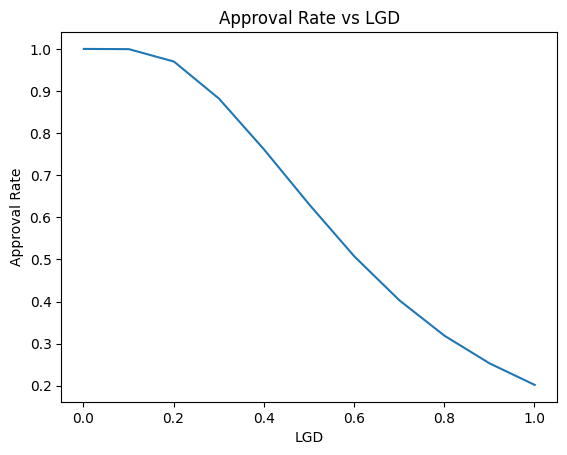

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(ev_table["LGD"], ev_table["approval_rate"])
plt.xlabel("LGD")
plt.ylabel("Approval Rate")
plt.title("Approval Rate vs LGD")
plt.savefig("../public/approval_rate_vs_LGD.png", dpi=300, bbox_inches="tight")
plt.show()

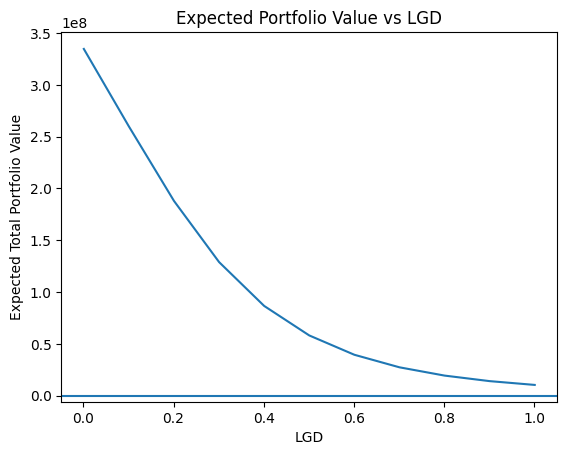

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(ev_table["LGD"], ev_table["expected_total_value"])
plt.xlabel("LGD")
plt.ylabel("Expected Total Portfolio Value")
plt.title("Expected Portfolio Value vs LGD")
plt.axhline(0)
plt.show()

## Optimal PD threshold
Now I calculate what the threshold for the probability of default should be, and what does this mean for the approval rate and the portfolio expected value (for the customers on the test split).

$$\tau^*=arg \max_{\tau} \text{Expected Portfolio Value}$$

In [21]:
import numpy as np
import matplotlib.pyplot as plt

L = X_test["loan_amnt"].to_numpy()
r = (X_test["int_rate"].to_numpy() / 100.0)
pd_pred = test_probs
LGD = 0.8  # choose one scenario

thresholds = np.linspace(0.01, 0.5, 100)
values = []
approval_rates = []

for t in thresholds:
    approve = pd_pred < t

    EL  = pd_pred * LGD * L
    EI  = (1 - pd_pred) * r * L
    ENV = EI - EL

    total_value = ENV[approve].sum()

    values.append(total_value)
    approval_rates.append(approve.mean())

optimal_idx = np.argmax(values)

print("Optimal PD threshold:", thresholds[optimal_idx])
print("Optimal approval rate:", approval_rates[optimal_idx])
print("Max expected value:", values[optimal_idx])

Optimal PD threshold: 0.11888888888888888
Optimal approval rate: 0.30125111350431444
Max expected value: 16914483.488533076


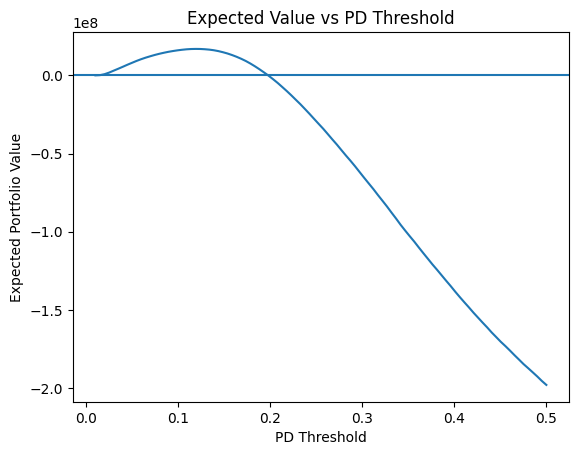

In [25]:
plt.figure()
plt.plot(thresholds, values)
plt.xlabel("PD Threshold")
plt.ylabel("Expected Portfolio Value")
plt.title("Expected Value vs PD Threshold")
plt.axhline(0)
plt.savefig("../public/optimal_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

## Risk-Return Frontier
I calculate the marginal value of approving borrowers, the riskier they get. This shows the diminishing return of riskier loans.

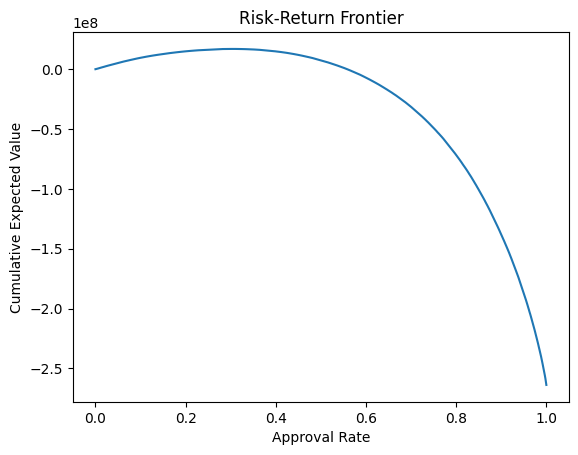

In [27]:
order = np.argsort(pd_pred)

sorted_ENV = ((1 - pd_pred) * r * L - pd_pred * LGD * L)[order]

cumulative_value = np.cumsum(sorted_ENV)
approval_rates = np.arange(1, len(sorted_ENV)+1) / len(sorted_ENV)

plt.figure()
plt.plot(approval_rates, cumulative_value)
plt.xlabel("Approval Rate")
plt.ylabel("Cumulative Expected Value")
plt.title("Risk-Return Frontier")
plt.savefig("../public/risk_return_frontier.png", dpi=300, bbox_inches="tight")
plt.show()